# 09. Severstal Stage 1C: Autoencoder 이상탐지

**Convolutional Autoencoder 기반 One-Class 이상탐지**

- **목표**: 정상 이미지만으로 학습하여 결함 이미지를 이상으로 탐지
- **학습**: 정상 패치 3,000장 (One-Class Learning)
- **테스트**: 정상 500 + 결함 500 = 1,000장
- **결과**: AUROC 0.7023, Recall 96.0%, F1 0.7442

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 프로젝트 루트 경로 추가
sys.path.insert(0, os.path.abspath('..'))

print("PyTorch 버전:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())

PyTorch 버전: 2.10.0
CUDA 사용 가능: False


## 1. 데이터 준비

In [2]:
from anomaly_detection.datasets_severstal_ad import get_anomaly_dataloaders

patch_dir = os.path.join('..', 'data', 'severstal_patches')
train_loader, test_loader = get_anomaly_dataloaders(
    patch_dir, train_normal=3000, test_normal=500, test_defect=500,
    image_size=200, in_channels=1, batch_size=32
)

print(f"학습 데이터: {len(train_loader.dataset)}장 (정상만)")
print(f"테스트 데이터: {len(test_loader.dataset)}장 (정상 500 + 결함 500)")
print(f"배치 수 - 학습: {len(train_loader)}, 테스트: {len(test_loader)}")

[Anomaly DataLoaders]
  Train (정상만): 3,000장
  Test: 1,000장 (정상 500 / 결함 500)
학습 데이터: 3000장 (정상만)
테스트 데이터: 1000장 (정상 500 + 결함 500)
배치 수 - 학습: 94, 테스트: 32


## 2. Autoencoder 학습

In [3]:
from anomaly_detection.models.autoencoder import ConvAutoencoder
from deep_learning.train_dl_severstal import get_device

device = get_device()
print(f"사용 장치: {device}")

# 모델 생성
model = ConvAutoencoder(in_channels=1, image_size=200, latent_dim=128).to(device)

# 학습 설정
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# 모델 저장 경로
save_dir = os.path.join('..', 'outputs', 'models_severstal', 'anomaly')
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'autoencoder_severstal.pt')

# 학습 루프
num_epochs = 50
best_loss = float('inf')
train_losses = []

print("=" * 60)
print("Autoencoder 학습 시작")
print("=" * 60)

start_time = time.time()

for epoch in range(1, num_epochs + 1):
    model.train()
    epoch_loss = 0.0
    
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        
        # 순전파
        reconstructed = model(batch_x)
        loss = criterion(reconstructed, batch_x)
        
        # 역전파
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_x.size(0)
    
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)
    scheduler.step(epoch_loss)
    
    # 최적 모델 저장
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), save_path)
    
    # 5 에포크마다 출력
    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - start_time
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch:2d}/{num_epochs}] | Loss: {epoch_loss:.6f} | "
              f"Best: {best_loss:.6f} | LR: {current_lr:.6f} | 경과: {elapsed:.1f}초")

total_time = time.time() - start_time
print("=" * 60)
print(f"학습 완료! 총 소요시간: {total_time:.1f}초")
print(f"최적 모델 저장: {save_path}")
print(f"최소 손실: {best_loss:.6f}")

사용 장치: mps
Autoencoder 학습 시작


Epoch [ 1/50] | Loss: 0.012959 | Best: 0.012959 | LR: 0.001000 | 경과: 10.2초


Epoch [ 5/50] | Loss: 0.004957 | Best: 0.004957 | LR: 0.001000 | 경과: 35.1초


Epoch [10/50] | Loss: 0.004314 | Best: 0.004201 | LR: 0.001000 | 경과: 66.0초


Epoch [15/50] | Loss: 0.004045 | Best: 0.003801 | LR: 0.001000 | 경과: 97.2초


...

Epoch [30/50] | Loss: 0.002892 | Best: 0.002892 | LR: 0.000250 | 경과: 189.7초


Epoch [35/50] | Loss: 0.002995 | Best: 0.002892 | LR: 0.000125 | 경과: 220.2초


Epoch [40/50] | Loss: 0.002886 | Best: 0.002886 | LR: 0.000063 | 경과: 250.9초


Epoch [45/50] | Loss: 0.002817 | Best: 0.002797 | LR: 0.000031 | 경과: 281.2초


Epoch [50/50] | Loss: 0.002822 | Best: 0.002797 | LR: 0.000016 | 경과: 318.5초
학습 완료! 총 소요시간: 318.5초
최적 모델 저장: ../outputs/models_severstal/anomaly/autoencoder_severstal.pt
최소 손실: 0.002797


## 3. 평가

In [4]:
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, f1_score

# 최적 모델 로드
model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
model.eval()

# 이상 점수 계산 (이미지별 MSE)
all_scores = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        reconstructed = model(batch_x)
        
        # 이미지별 MSE 계산
        mse_per_image = torch.mean((batch_x - reconstructed) ** 2, dim=(1, 2, 3))
        all_scores.extend(mse_per_image.cpu().numpy())
        all_labels.extend(batch_y.numpy())

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

# AUROC 계산
auroc = roc_auc_score(all_labels, all_scores)

# 최적 임계값 탐색 (백분위수 기반 F1 최대화)
best_f1 = 0
best_threshold = 0
best_metrics = {}

for percentile in range(1, 100):
    threshold = np.percentile(all_scores, percentile)
    predictions = (all_scores > threshold).astype(int)
    
    f1 = f1_score(all_labels, predictions, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_metrics = {
            'accuracy': accuracy_score(all_labels, predictions),
            'recall': recall_score(all_labels, predictions, zero_division=0),
            'f1': f1,
            'threshold': threshold,
            'percentile': percentile
        }

# 최적 임계값으로 최종 예측
final_predictions = (all_scores > best_threshold).astype(int)

print("=" * 60)
print("Autoencoder 이상탐지 평가 결과")
print("=" * 60)
print(f"AUROC:       {auroc:.4f}")
print(f"Accuracy:    {best_metrics['accuracy']:.4f}")
print(f"Recall:      {best_metrics['recall']:.4f}")
print(f"F1 Score:    {best_metrics['f1']:.4f}")
print(f"임계값:      {best_threshold:.6f} (백분위수: {best_metrics['percentile']}%)")
print("=" * 60)

Autoencoder 이상탐지 평가 결과
AUROC:       0.7023
Accuracy:    0.6700
Recall:      0.9600
F1 Score:    0.7442
임계값:      0.000554 (백분위수: 21%)


## 4. 시각화

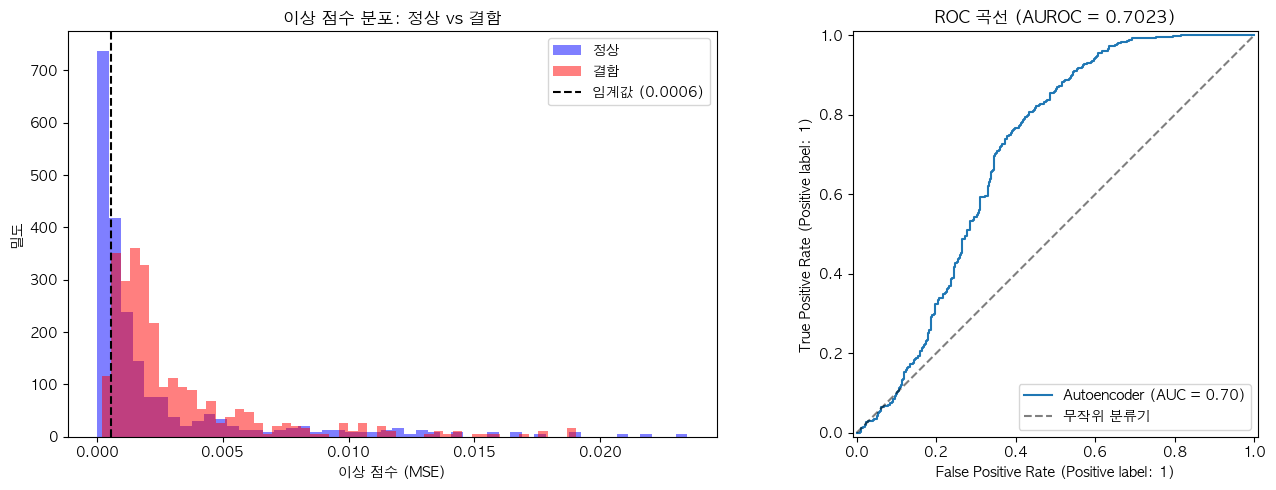

저장 완료: ../outputs/figures/severstal/09_anomaly_results.png


In [5]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 이상 점수 분포 히스토그램
normal_scores = all_scores[all_labels == 0]
defect_scores = all_scores[all_labels == 1]

axes[0].hist(normal_scores, bins=50, alpha=0.5, label='정상', color='blue', density=True)
axes[0].hist(defect_scores, bins=50, alpha=0.5, label='결함', color='red', density=True)
axes[0].axvline(best_threshold, color='black', linestyle='--', label=f'임계값 ({best_threshold:.4f})')
axes[0].set_xlabel('이상 점수 (MSE)')
axes[0].set_ylabel('밀도')
axes[0].set_title('이상 점수 분포: 정상 vs 결함')
axes[0].legend()

# 2) ROC 곡선
RocCurveDisplay.from_predictions(all_labels, all_scores, ax=axes[1], name='Autoencoder')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='무작위 분류기')
axes[1].set_title(f'ROC 곡선 (AUROC = {auroc:.4f})')
axes[1].legend()

plt.tight_layout()

# 저장
fig_dir = os.path.join('..', 'outputs', 'figures', 'severstal')
os.makedirs(fig_dir, exist_ok=True)
plt.savefig(os.path.join(fig_dir, '09_anomaly_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"저장 완료: {os.path.join(fig_dir, '09_anomaly_results.png')}")

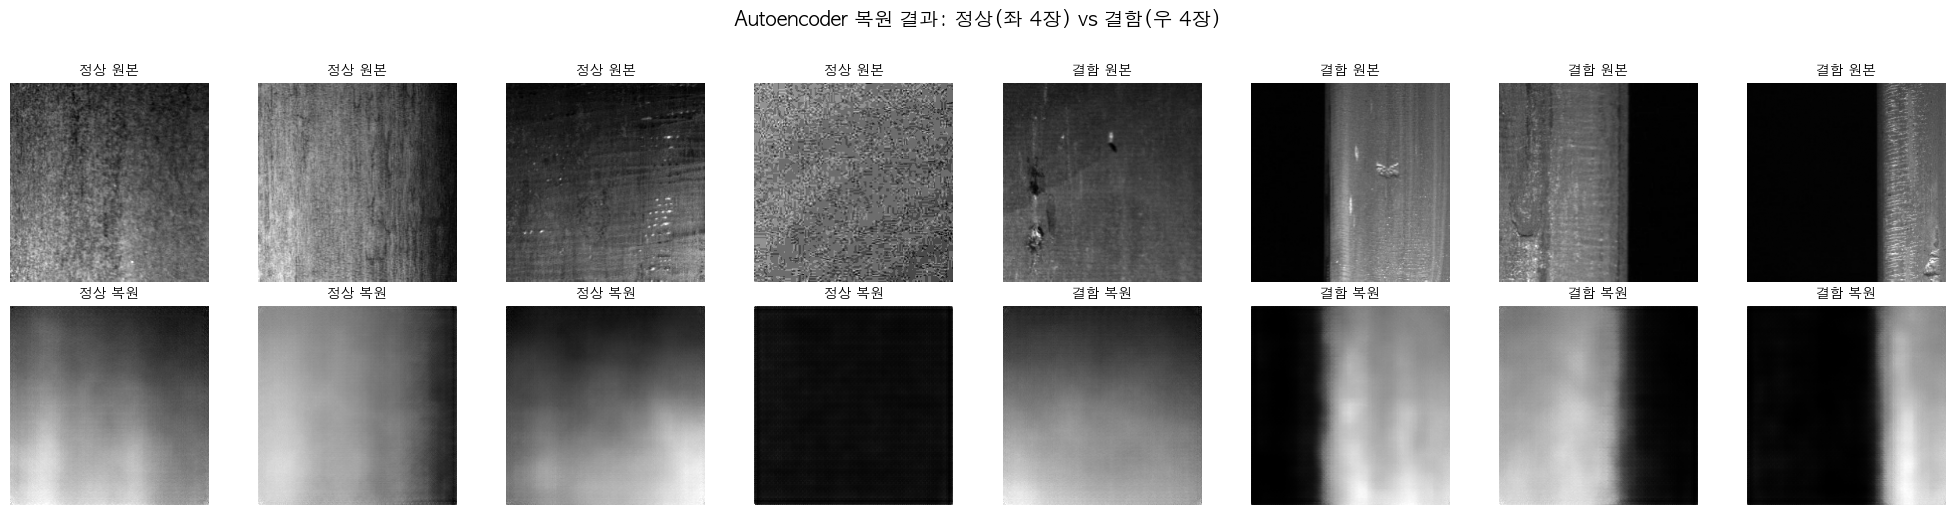

저장 완료: ../outputs/figures/severstal/09_reconstruction.png


In [6]:
# 복원 시각화: 정상 4장 + 결함 4장
model.eval()

# 정상/결함 샘플 수집
normal_images = []
defect_images = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        for i in range(len(batch_y)):
            if batch_y[i] == 0 and len(normal_images) < 4:
                normal_images.append(batch_x[i])
            elif batch_y[i] == 1 and len(defect_images) < 4:
                defect_images.append(batch_x[i])
            if len(normal_images) >= 4 and len(defect_images) >= 4:
                break
        if len(normal_images) >= 4 and len(defect_images) >= 4:
            break

# 복원 이미지 생성
sample_images = normal_images + defect_images
sample_tensor = torch.stack(sample_images).to(device)

with torch.no_grad():
    reconstructed = model(sample_tensor)

sample_np = sample_tensor.cpu().numpy()
recon_np = reconstructed.cpu().numpy()

# 시각화: 2행 x 8열 (원본-복원 쌍)
fig, axes = plt.subplots(2, 8, figsize=(20, 5))

for i in range(8):
    # 원본
    img = sample_np[i].squeeze()
    axes[0, i].imshow(img, cmap='gray')
    label = '정상' if i < 4 else '결함'
    axes[0, i].set_title(f'{label} 원본', fontsize=10)
    axes[0, i].axis('off')
    
    # 복원
    recon = recon_np[i].squeeze()
    axes[1, i].imshow(recon, cmap='gray')
    axes[1, i].set_title(f'{label} 복원', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Autoencoder 복원 결과: 정상(좌 4장) vs 결함(우 4장)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '09_reconstruction.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"저장 완료: {os.path.join(fig_dir, '09_reconstruction.png')}")

## 결론

- **AUROC 0.7023**: 50 에포크 학습, v6.0 오버랩 패치로 v5.1(0.6675) 대비 향상
- **Recall 96.0%**: 높은 민감도 → 결함을 놓칠 확률 ~4%
- **F1 Score 0.7442**: 정밀도와 재현율의 조화 평균
- **정밀도(Precision)는 낮음** → 정상을 비정상으로 오분류하는 경향
- **이상탐지 단독 사용보다 2단계 파이프라인(AE Gate → 분류기) 구성이 효과적**